In [11]:
import numpy as np
import pandas as pd
import os

lat_start, lat_end = 6.0, 38.0
lon_start, lon_end = 68.0, 98.0
step = 0.25

lat_edges = np.arange(lat_start, lat_end + step, step)
lon_edges = np.arange(lon_start, lon_end + step, step)

print("Latitude edges:", len(lat_edges))
print("Longitude edges:", len(lon_edges))

lat_edges[:10], lon_edges[:10]

Latitude edges: 129
Longitude edges: 121


(array([6.  , 6.25, 6.5 , 6.75, 7.  , 7.25, 7.5 , 7.75, 8.  , 8.25]),
 array([68.  , 68.25, 68.5 , 68.75, 69.  , 69.25, 69.5 , 69.75, 70.  ,
        70.25]))

In [12]:
grid_cells = []
grid_id = 1

for i in range(len(lat_edges) - 1):
    for j in range(len(lon_edges) - 1):
        lat_min = lat_edges[i]
        lat_max = lat_edges[i + 1]
        lon_min = lon_edges[j]
        lon_max = lon_edges[j + 1]

        grid_cells.append([
            grid_id,
            lat_min, lat_max,
            lon_min, lon_max,
            (lat_min + lat_max) / 2,
            (lon_min + lon_max) / 2
        ])
        grid_id += 1

df_grid = pd.DataFrame(
    grid_cells,
    columns=["grid_id", "lat_min", "lat_max",
             "lon_min", "lon_max",
             "lat_center", "lon_center"]
)

df_grid.head()

,grid_id,lat_min,lat_max,lon_min,lon_max,lat_center,lon_center
0,1,6.0,6.25,68.00,68.25,6.125,68.125
1,2,6.0,6.25,68.25,68.50,6.125,68.375
2,3,6.0,6.25,68.50,68.75,6.125,68.625
3,4,6.0,6.25,68.75,69.00,6.125,68.875
4,5,6.0,6.25,69.00,69.25,6.125,69.125


In [13]:
os.makedirs("../data_processed/2_days/grid", exist_ok=True)
df_grid.to_parquet("../data_processed/grid/grid_definition.parquet")

print("Saved grid_definition.parquet with", len(df_grid), "rows.")

Saved grid_definition.parquet with 15360 rows.


In [14]:
print("Expected cells:", 128 * 120)
print("Generated cells:", len(df_grid))

Expected cells: 15360
Generated cells: 15360


<Axes: xlabel='lon_center', ylabel='lat_center'>

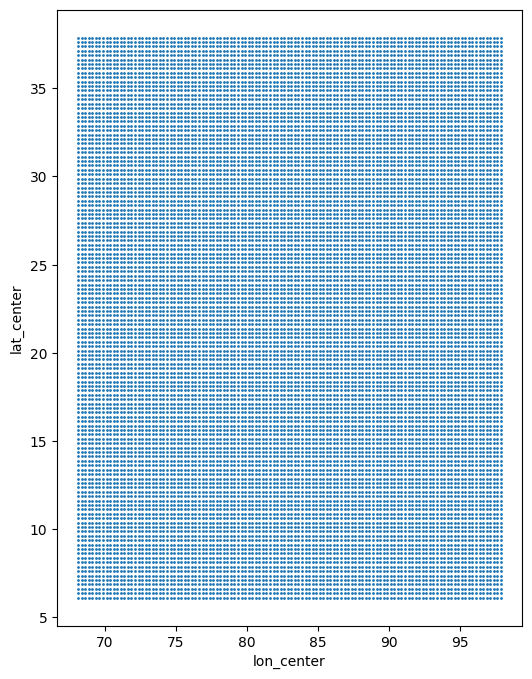

In [15]:
df_grid.plot.scatter(x="lon_center", y="lat_center", s=1, figsize=(6,8))